In [12]:
from pathlib import Path
import numpy as np
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

In [11]:
# ============================================================
# USER SETTINGS
# ============================================================
input_nc = Path("../data/GPGP_aug2020_3D.nc")
out_dir = Path("../data")
out_stem = "MITgcm_interp_aug2020"

# MITgcm target grid arrays (cell centers)
x_mit = np.arange(0.0, 384 * 500.0, 500.0, dtype=float)
y_mit = np.arange(0.0, 384 * 500.0, 500.0, dtype=float)

delR = np.array([
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.2, 2.4, 2.6, 2.9, 3.1,
    3.4, 3.7, 4.0, 4.4, 4.8,
    5.2, 5.7, 6.2, 6.8, 7.4,
    8.1, 8.8, 9.6, 10.5, 11.4,
    12.5, 13.6, 14.8, 16.2, 17.6,
    19.2, 21.0, 22.9, 24.9, 27.2,
    29.7, 32.4, 35.4, 38.6, 42.1,
    45.9, 50.0, 54.5, 59.4, 64.8,
    70.6, 77.0, 84.0, 91.5, 99.7,
    108.7, 118.5, 129.1, 140.8, 153.5,
    167.3, 182.4, 198.8, 216.7, 236.2,
    257.5, 280.7, 306.1, 328.5
], dtype=float)

z_mit = np.cumsum(delR) - 0.5 * delR

method_main = "linear"
method_fallback = "nearest"

# ============================================================
# HELPERS
# ============================================================
def find_first_present(ds, names):
    for n in names:
        if n in ds.variables or n in ds.coords:
            return n
    return None

def centers_to_faces_1d(xc):
    xc = np.asarray(xc, dtype=float)
    xf = np.empty(len(xc) + 1, dtype=float)
    xf[1:-1] = 0.5 * (xc[:-1] + xc[1:])
    xf[0] = xc[0] - 0.5 * (xc[1] - xc[0])
    xf[-1] = xc[-1] + 0.5 * (xc[-1] - xc[-2])
    return xf

def xy_to_lonlat(x, y, lon0, lat0):
    Re = 6371000.0
    lat = lat0 + (y / Re) * 180.0 / np.pi
    lon = lon0 + (x / (Re * np.cos(np.deg2rad(lat0)))) * 180.0 / np.pi
    return lon, lat

def fill_nan_vertical(arr, zsrc):
    out = arr.copy()
    nz, ny, nx = out.shape
    for j in range(ny):
        for i in range(nx):
            col = out[:, j, i]
            good = np.isfinite(col)
            if good.any():
                if good.sum() == 1:
                    col[:] = col[good][0]
                else:
                    col[~good] = np.interp(
                        zsrc[~good], zsrc[good], col[good],
                        left=col[good][0], right=col[good][-1]
                    )
            else:
                col[:] = 0.0
            out[:, j, i] = col
    return out

# ============================================================
# OPEN DATA
# ============================================================
ds = xr.open_dataset(input_nc)

u_name = find_first_present(ds, ["uo", "UO", "u", "U"])
v_name = find_first_present(ds, ["vo", "VO", "v", "V"])
lon_name = find_first_present(ds, ["longitude", "lon", "nav_lon"])
lat_name = find_first_present(ds, ["latitude", "lat", "nav_lat"])
z_name = find_first_present(ds, ["depth", "lev", "z"])
time_name = find_first_present(ds, ["time", "TIME"])

if None in [u_name, v_name, lon_name, lat_name, z_name]:
    raise ValueError("Could not automatically identify u, v, lon, lat, or depth variables.")

u_da = ds[u_name].isel({time_name: 0}) if time_name and time_name in ds[u_name].dims else ds[u_name]
v_da = ds[v_name].isel({time_name: 0}) if time_name and time_name in ds[v_name].dims else ds[v_name]

lon_src = np.asarray(ds[lon_name].values, dtype=float)
lat_src = np.asarray(ds[lat_name].values, dtype=float)
z_src = np.asarray(ds[z_name].values, dtype=float)

lon_sort_idx = np.argsort(lon_src)
lon_src = lon_src[lon_sort_idx]

u_src = np.asarray(u_da.values, dtype=np.float32)
v_src = np.asarray(v_da.values, dtype=np.float32)

# expected: (z, y, x)
u_src = u_src[:, :, lon_sort_idx]
v_src = v_src[:, :, lon_sort_idx]

# keep only needed depth range
iz = z_src <= z_mit.max()
z_src = z_src[iz]
u_src = u_src[iz, :, :]
v_src = v_src[iz, :, :]

# fill NaNs vertically
u_src = fill_nan_vertical(u_src, z_src).astype(np.float32)
v_src = fill_nan_vertical(v_src, z_src).astype(np.float32)

# ============================================================
# BUILD MITgcm U/V GRIDS FROM FILE EXTENT
# ============================================================
lon_w = float(np.nanmin(ds[lon_name].values))
lon_e = float(np.nanmax(ds[lon_name].values))
lat_s = float(np.nanmin(ds[lat_name].values))
lat_n = float(np.nanmax(ds[lat_name].values))

lon0 = 0.5 * (lon_w + lon_e)
lat0 = 0.5 * (lat_s + lat_n)

x_u = centers_to_faces_1d(x_mit)
y_u = y_mit

x_v = x_mit
y_v = centers_to_faces_1d(y_mit)

X_u, Y_u = np.meshgrid(x_u, y_u)
X_v, Y_v = np.meshgrid(x_v, y_v)

Lon_u, Lat_u = xy_to_lonlat(X_u, Y_u, lon0, lat0)
Lon_v, Lat_v = xy_to_lonlat(X_v, Y_v, lon0, lat0)

# match longitude convention
if lon_src.max() > 180.0:
    Lon_u = np.mod(Lon_u, 360.0)
    Lon_v = np.mod(Lon_v, 360.0)
else:
    Lon_u = ((Lon_u + 180.0) % 360.0) - 180.0
    Lon_v = ((Lon_v + 180.0) % 360.0) - 180.0

# ============================================================
# INTERPOLATORS
# ============================================================
Fu = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    u_src,
    method=method_main,
    bounds_error=False,
    fill_value=np.nan
)
Fv = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    v_src,
    method=method_main,
    bounds_error=False,
    fill_value=np.nan
)

Fu_nn = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    u_src,
    method=method_fallback,
    bounds_error=False,
    fill_value=0.0
)
Fv_nn = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    v_src,
    method=method_fallback,
    bounds_error=False,
    fill_value=0.0
)

# ============================================================
# INTERPOLATE U TO U-POINTS, LEVEL BY LEVEL
# ============================================================
Nr = len(z_mit)
Ny_u, Nx_u = Lon_u.shape
u_mit = np.empty((Nr, Ny_u, Nx_u), dtype=np.float32)

for k, zk in enumerate(z_mit):
    print(f"Interpolating U level {k+1}/{Nr} at z = {zk:.2f} m")

    pts_u = np.column_stack([
        np.full(Lon_u.size, zk, dtype=float),
        Lat_u.ravel(),
        Lon_u.ravel()
    ])

    uk = Fu(pts_u).reshape(Ny_u, Nx_u)
    mask = ~np.isfinite(uk)
    if mask.any():
        uk[mask] = Fu_nn(pts_u).reshape(Ny_u, Nx_u)[mask]

    u_mit[k, :, :] = uk.astype(np.float32)

# ============================================================
# INTERPOLATE V TO V-POINTS, LEVEL BY LEVEL
# ============================================================
Ny_v, Nx_v = Lon_v.shape
v_mit = np.empty((Nr, Ny_v, Nx_v), dtype=np.float32)

for k, zk in enumerate(z_mit):
    print(f"Interpolating V level {k+1}/{Nr} at z = {zk:.2f} m")

    pts_v = np.column_stack([
        np.full(Lon_v.size, zk, dtype=float),
        Lat_v.ravel(),
        Lon_v.ravel()
    ])

    vk = Fv(pts_v).reshape(Ny_v, Nx_v)
    mask = ~np.isfinite(vk)
    if mask.any():
        vk[mask] = Fv_nn(pts_v).reshape(Ny_v, Nx_v)[mask]

    v_mit[k, :, :] = vk.astype(np.float32)

# ============================================================
# SAVE
# ============================================================
out_dir.mkdir(parents=True, exist_ok=True)

u_bin = out_dir / f"{out_stem}_uvel.bin"
v_bin = out_dir / f"{out_stem}_vvel.bin"
nc_out = out_dir / f"{out_stem}.nc"

np.asarray(u_mit, dtype=">f4").tofile(u_bin)
np.asarray(v_mit, dtype=">f4").tofile(v_bin)

ds_out = xr.Dataset(
    data_vars={
        "u_mit": (("z", "y_u", "x_u"), u_mit),
        "v_mit": (("z", "y_v", "x_v"), v_mit),
        "lon_u": (("y_u", "x_u"), Lon_u),
        "lat_u": (("y_u", "x_u"), Lat_u),
        "lon_v": (("y_v", "x_v"), Lon_v),
        "lat_v": (("y_v", "x_v"), Lat_v),
    },
    coords={
        "z": z_mit,
        "x_u": x_u,
        "y_u": y_u,
        "x_v": x_v,
        "y_v": y_v,
    },
    attrs={
        "source_file": str(input_nc),
        "interp_method": method_main,
        "fallback_method": method_fallback,
    }
)

ds_out.to_netcdf(nc_out)

print("Saved:")
print(" ", u_bin)
print(" ", v_bin)
print(" ", nc_out)
print("u_mit shape:", u_mit.shape, "min/max:", np.nanmin(u_mit), np.nanmax(u_mit))
print("v_mit shape:", v_mit.shape, "min/max:", np.nanmin(v_mit), np.nanmax(v_mit))

Interpolating U level 1/84 at z = 1.00 m
Interpolating U level 2/84 at z = 3.00 m
Interpolating U level 3/84 at z = 5.00 m
Interpolating U level 4/84 at z = 7.00 m
Interpolating U level 5/84 at z = 9.00 m
Interpolating U level 6/84 at z = 11.00 m
Interpolating U level 7/84 at z = 13.00 m
Interpolating U level 8/84 at z = 15.00 m
Interpolating U level 9/84 at z = 17.00 m
Interpolating U level 10/84 at z = 19.00 m
Interpolating U level 11/84 at z = 21.00 m
Interpolating U level 12/84 at z = 23.00 m
Interpolating U level 13/84 at z = 25.00 m
Interpolating U level 14/84 at z = 27.00 m
Interpolating U level 15/84 at z = 29.00 m
Interpolating U level 16/84 at z = 31.00 m
Interpolating U level 17/84 at z = 33.00 m
Interpolating U level 18/84 at z = 35.00 m
Interpolating U level 19/84 at z = 37.00 m
Interpolating U level 20/84 at z = 39.00 m
Interpolating U level 21/84 at z = 41.00 m
Interpolating U level 22/84 at z = 43.00 m
Interpolating U level 23/84 at z = 45.00 m
Interpolating U level 24/

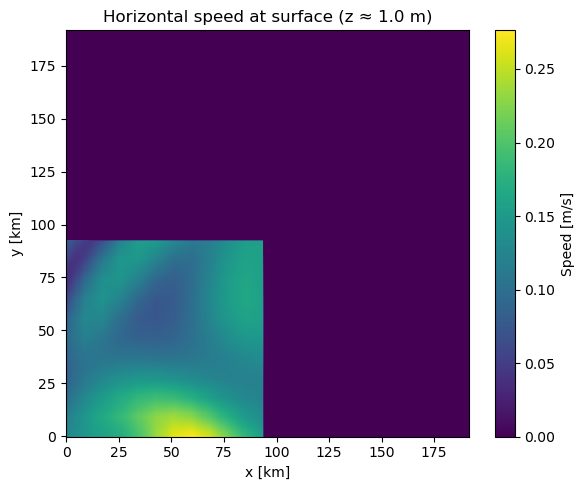

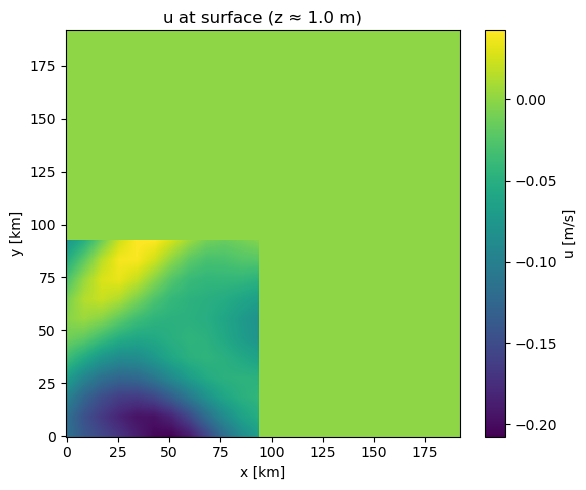

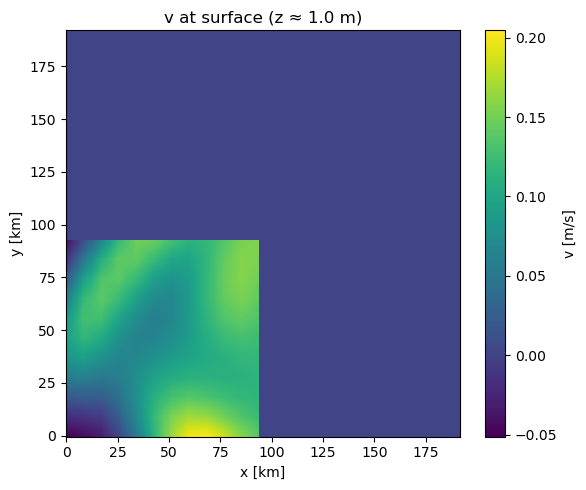

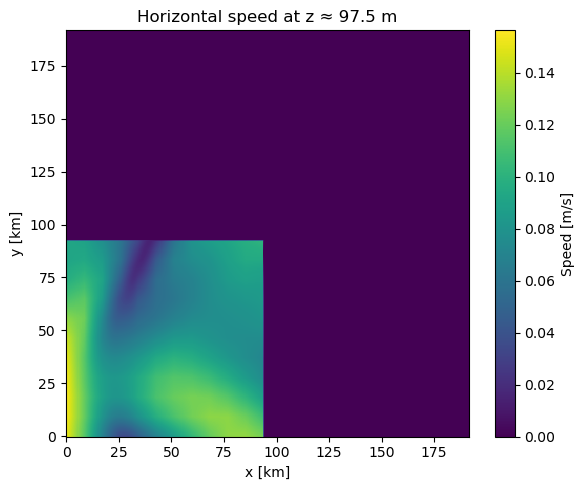

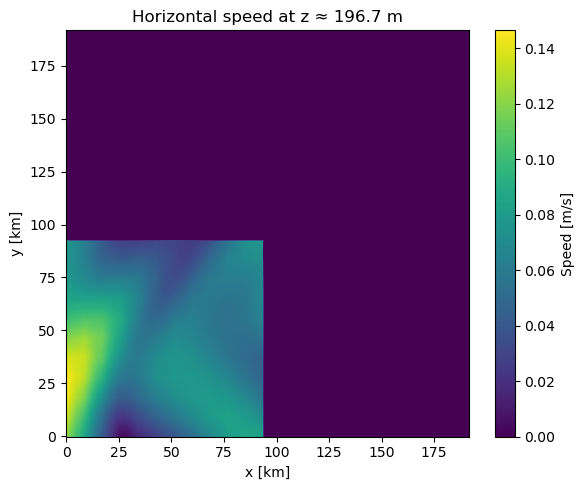

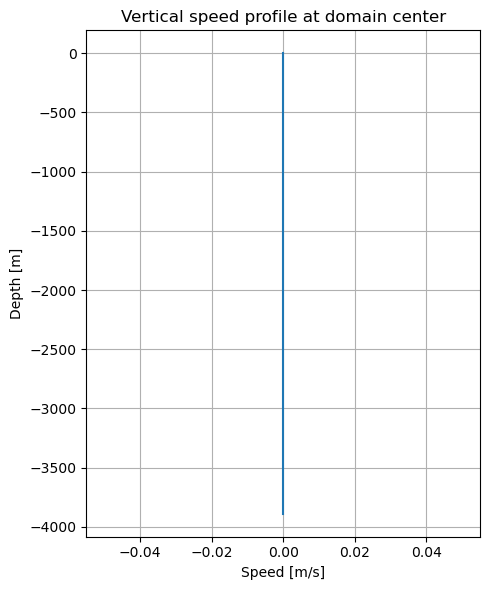

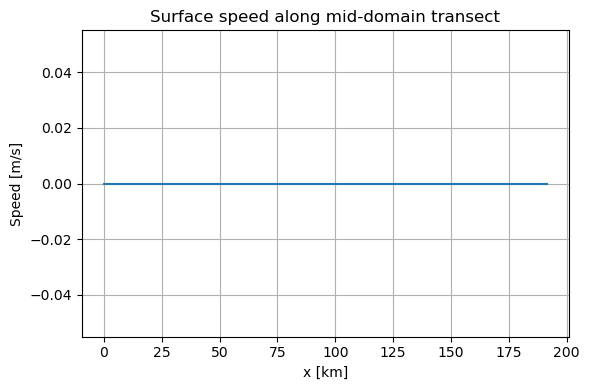

In [13]:
# -------------------------
# QC plots
# -------------------------
speed_u = 0.5 * (u_mit[:, :, :-1] + u_mit[:, :, 1:])          # to tracer x
speed_v = 0.5 * (v_mit[:, :-1, :] + v_mit[:, 1:, :])          # to tracer y

ny_plot = min(speed_u.shape[1], speed_v.shape[1])
nx_plot = min(speed_u.shape[2], speed_v.shape[2])

u_c = speed_u[:, :ny_plot, :nx_plot]
v_c = speed_v[:, :ny_plot, :nx_plot]
speed3d = np.hypot(u_c, v_c)

Xc, Yc = np.meshgrid(x_mit[:nx_plot], y_mit[:ny_plot])

k_surface = 0
k_100m = np.argmin(np.abs(z_mit - 100.0))
k_200m = np.argmin(np.abs(z_mit - 200.0))

# 1) Horizontal speed at surface
plt.figure(figsize=(6, 5))
plt.pcolormesh(Xc / 1000.0, Yc / 1000.0, speed3d[k_surface], shading="auto")
plt.colorbar(label="Speed [m/s]")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title(f"Horizontal speed at surface (z ≈ {z_mit[k_surface]:.1f} m)")
plt.tight_layout()
plt.show()

# 2) u at surface
plt.figure(figsize=(6, 5))
plt.pcolormesh(X_u / 1000.0, Y_u / 1000.0, u_mit[k_surface], shading="auto")
plt.colorbar(label="u [m/s]")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title(f"u at surface (z ≈ {z_mit[k_surface]:.1f} m)")
plt.tight_layout()
plt.show()

# 3) v at surface
plt.figure(figsize=(6, 5))
plt.pcolormesh(X_v / 1000.0, Y_v / 1000.0, v_mit[k_surface], shading="auto")
plt.colorbar(label="v [m/s]")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title(f"v at surface (z ≈ {z_mit[k_surface]:.1f} m)")
plt.tight_layout()
plt.show()

# 4) Horizontal speed at ~100 m
plt.figure(figsize=(6, 5))
plt.pcolormesh(Xc / 1000.0, Yc / 1000.0, speed3d[k_100m], shading="auto")
plt.colorbar(label="Speed [m/s]")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title(f"Horizontal speed at z ≈ {z_mit[k_100m]:.1f} m")
plt.tight_layout()
plt.show()

# 5) Horizontal speed at ~200 m
plt.figure(figsize=(6, 5))
plt.pcolormesh(Xc / 1000.0, Yc / 1000.0, speed3d[k_200m], shading="auto")
plt.colorbar(label="Speed [m/s]")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title(f"Horizontal speed at z ≈ {z_mit[k_200m]:.1f} m")
plt.tight_layout()
plt.show()

# 6) Vertical profile at domain center
iy_mid = len(y_mit) // 2
ix_mid = len(x_mit) // 2
profile_mid = speed3d[:, iy_mid, ix_mid]

plt.figure(figsize=(5, 6))
plt.plot(profile_mid, -z_mit)
plt.xlabel("Speed [m/s]")
plt.ylabel("Depth [m]")
plt.title("Vertical speed profile at domain center")
plt.grid(True)
plt.tight_layout()
plt.show()

# 7) Surface speed along mid-domain transect
surface_profile = speed3d[k_surface, iy_mid, :]

plt.figure(figsize=(6, 4))
plt.plot(x_mit[:nx_plot] / 1000.0, surface_profile)
plt.xlabel("x [km]")
plt.ylabel("Speed [m/s]")
plt.title("Surface speed along mid-domain transect")
plt.grid(True)
plt.tight_layout()
plt.show()